# Индекс цифрового благополучия пользователей ВКонтакте

Ноутбук повторяет расчёт из `report.pdf` шаг за шагом: данные → тональность → признаки → формула → результаты → проверка устойчивости.
Весь код лежит в `src/`, здесь — только вызовы и пояснения.

**Идея.** Счастье напрямую не измерить, но у субъективного благополучия есть понятные части: эмоции, отношения, вовлечённость, режим. Каждая оставляет след в соцсети. Из этих следов собирается индекс от 0 до 100.

In [1]:
import json, warnings
import numpy as np, pandas as pd
from IPython.display import Image, display
warnings.filterwarnings("ignore")
pd.set_option("display.precision", 3)

from src import config
from src.pipeline import load_data, compute
from src.sentiment import get_analyzer
from src.group_topics import classify_group, topic_class
from src.happiness_index import components, dwi, naive_index
from src import robustness as rb, visualize as vz

## 1. Данные

`data.json` — обезличенный корпус: ID заменены HMAC-хэшами, из текстов убраны имена, ссылки и контакты.

In [2]:
data = load_data()
print("пользователей:", len(data), "| публикаций:", sum(len(u["posts"]) for u in data))
u = data[0]
{k: (v if not isinstance(v, (dict, list)) else f"<{type(v).__name__}, {len(v)} эл.>") for k, v in u.items()}

пользователей: 312 | публикаций: 16915


{'id': '515274cc4d5b1828',
 'city': 'Нижнекамск',
 'region': 'Республика Татарстан',
 'age': 21,
 'gender': 'male',
 'university': 'Нижнекамский филиал МГЭУ',
 'photos_num': 45,
 'videos_num': 2,
 'audio_num': 9,
 'self_posts_num': 4,
 'reposts_num': 3,
 'followers_num': 102,
 'groups_num': 35,
 'friends_num': 49,
 'posts': '<dict, 7 эл.>',
 'groups': '<dict, 16 эл.>',
 'friends': '<list, 49 эл.>',
 'photo_analysis': '<dict, 5 эл.>',
 'collected_at': '25.09.2026'}

In [3]:
first_post = next(iter(u["posts"].values()))
first_post

{'text': 'Потерял кошелёк с документами в автобусе. Если кто найдёт, верните пожалуйста 😤',
 'date': '28.08.2026 00:39:43',
 'is_repost': False,
 'likes': 0,
 'comments': 1,
 'reposts': 0,
 'views': 27,
 'has_photo': False,
 'commenters': ['8e1a43e3b9bc7f56']}

## 2. Тональность

Словарный метод: KartaSlovSent + лемматизация pymorphy3 + отрицания, усилители и эмодзи. Если установлена модель Dostoevsky, `get_analyzer()` возьмёт её.

In [4]:
sa = get_analyzer()
print(sa.name)
for t in ["Какой классный день! Гуляли по набережной 😊", "Опять задержали зарплату, ужасная контора",
          "Кто знает хорошего стоматолога в Азино?", "Это совсем не хорошо", "Просто отлично, как всегда..."]:
    s = sa.score(t)
    print(f"{s['score']:+.2f}  pos={s['pos']:.2f} neg={s['neg']:.2f}  {t}")

lexicon (KartaSlovSent + эмодзи)
+0.71  pos=0.99 neg=0.00  Какой классный день! Гуляли по набережной 😊
-0.14  pos=0.01 neg=0.46  Опять задержали зарплату, ужасная контора
+0.22  pos=0.27 neg=0.01  Кто знает хорошего стоматолога в Азино?
-0.50  pos=0.00 neg=0.98  Это совсем не хорошо
+0.61  pos=0.98 neg=0.00  Просто отлично, как всегда...


Последний пример — сарказм. Словарь его не понимает, это одно из ограничений метода. Качество на контрольной выборке из 90 размеченных текстов:

In [5]:
from src.main import sentiment_validation
pd.DataFrame(sentiment_validation(sa)).T.round(3)

,precision,recall,f1-score,support
neg,0.917,0.733,0.815,30.000
neu,0.774,0.800,0.787,30.000
pos,0.857,1.000,0.923,30.000
accuracy,0.844,0.844,0.844,0.844
macro avg,0.849,0.844,0.842,90.000
weighted avg,0.849,0.844,0.842,90.000


## 3. Сообщества

14 тем по словарю маркеров → 4 класса: конструктивные, информационные, развлекательные, негативные.

In [6]:
for name, desc, act in [("Бег Казань | RunKazan", "совместные пробежки, марафон", "Спорт"),
                        ("Грустные цитаты", "боль, одиночество, разбитое сердце", "Цитаты"),
                        ("Мемы про Казань", "смешные картинки", "Юмор"),
                        ("Злой водитель Казани", "разборки на дорогах, мат не банится", "Авто")]:
    t = classify_group(name, desc, act)
    print(f"{name:25s} -> {t:10s} ({topic_class(t)})")

Бег Казань | RunKazan     -> sport      (constructive)
Грустные цитаты           -> sad        (negative)
Мемы про Казань           -> humor      (entertainment)
Злой водитель Казани      -> toxic      (negative)


## 4. Признаки и компоненты

$$\text{ИЦБ} = 100\cdot\frac{\sum_k w_k C_k}{\sum_k w_k},\qquad C_k\in[0,1]$$

| | формула |
|---|---|
| E | $\frac{P+a}{P+N+a+b}$, Beta(2,2) |
| R | $0.4F_s(\ln(1+f)) + 0.4F_s(\ln(1+c)) + 0.2\frac{k_f+a}{k+a+b}$ |
| A | $0.4F_s(\ln(1+\tilde e)) + 0.3(1-e^{-m/\lambda}) + 0.3\frac{o+1}{n+4}$ |
| G | $\mathrm{clip}(0.6\tilde c + 0.4H_c - \tilde n, 0, 1)$ |
| B | $\mathrm{clip}(1 - \frac{\tilde\nu-\nu_0}{\nu_{max}-\nu_0}, 0, 1)$ |
| V | $\frac{n_{face}+n_{group}+n_{smile}+a}{3n_{ph}+a+b}$ |

$F_s$ — перцентильный ранг внутри сегмента «пол × возрастная группа».

In [7]:
res, meta, cache = compute(verbose=False)
print(meta["sentiment_backend"], "| веса:", config.WEIGHTS)
res[["E", "R", "G", "A", "B", "V", "DWI"]].describe().T

lexicon (KartaSlovSent + эмодзи) | веса: {'E': 0.3, 'R': 0.25, 'G': 0.15, 'A': 0.15, 'B': 0.1, 'V': 0.05}


,count,mean,std,min,25%,50%,75%,max
E,312.0,0.680,0.140,0.263,0.572,0.689,0.796,0.924
R,312.0,0.543,0.196,0.148,0.383,0.542,0.680,0.941
G,312.0,0.517,0.180,0.000,0.405,0.563,0.648,0.827
A,312.0,0.334,0.150,0.074,0.223,0.333,0.448,0.694
B,312.0,0.858,0.163,0.250,0.770,0.907,1.000,1.000
V,299.0,0.282,0.140,0.019,0.181,0.260,0.370,0.727
DWI,312.0,56.795,12.514,29.287,47.664,56.557,65.792,84.684


In [8]:
res[["city", "age", "gender", "own_posts", "friends", "E", "R", "G", "A", "B", "V", "DWI"]].head(8)

,city,age,gender,own_posts,friends,E,R,G,A,B,V,DWI
id,,,,,,,,,,,,
515274cc4d5b1828,Нижнекамск,21,male,4,49,0.512,0.233,0.338,0.166,0.250,0.144,31.998
c62d515e824f75cb,Казань,28,female,23,828,0.796,0.732,0.571,0.506,0.840,0.558,69.515
bf9cd7d6051cc856,Казань,34,female,13,82,0.571,0.353,0.239,0.198,1.000,0.110,43.044
8e73d4607317993a,Альметьевск,21,female,6,408,0.668,0.692,0.619,0.387,0.618,NaN,61.699
f11acb1695634f4e,Набережные Челны,28,female,4,92,0.765,0.470,0.376,0.298,0.875,0.279,54.939
1966f2e3856cc03a,Казань,26,female,1,549,0.545,0.532,0.803,0.520,1.000,0.617,62.612
b63ed5b5aee934ff,Казань,37,female,19,56,0.320,0.361,0.210,0.186,0.761,0.026,32.296
5acdc8a6f859b9ef,Казань,38,female,99,69,0.612,0.493,0.538,0.423,0.867,0.156,54.542


## 5. Результаты

In [9]:
S = vz.statistics(res)
print(f"ИЦБ: среднее {S['dwi_mean']:.1f}, медиана {S['dwi_median']:.1f}, ст.откл. {S['dwi_std']:.1f}")
print(f"Пол: Манн–Уитни p = {S['gender']['p']:.3f}; возраст: Краскел–Уоллис p = {S['age']['p']:.3f}")
pd.DataFrame(S["spearman"], index=["rho", "p"]).T.sort_values("rho")

ИЦБ: среднее 56.8, медиана 56.6, ст.откл. 12.5
Пол: Манн–Уитни p = 0.717; возраст: Краскел–Уоллис p = 0.447


,rho,p
доля негативных сообществ,-0.593,4.722e-31
доля ночной активности,-0.233,3.678e-05
возраст,0.035,5.341e-01
число подписчиков,0.162,4.083e-03
разнообразие интересов,0.504,1.788e-21
число друзей,0.518,8.002e-23
частота постов,0.601,5.742e-32
доля конструктивных сообществ,0.666,2.321e-41
наивный индекс,0.748,3.640e-57
медиана отклика,0.749,1.768e-57


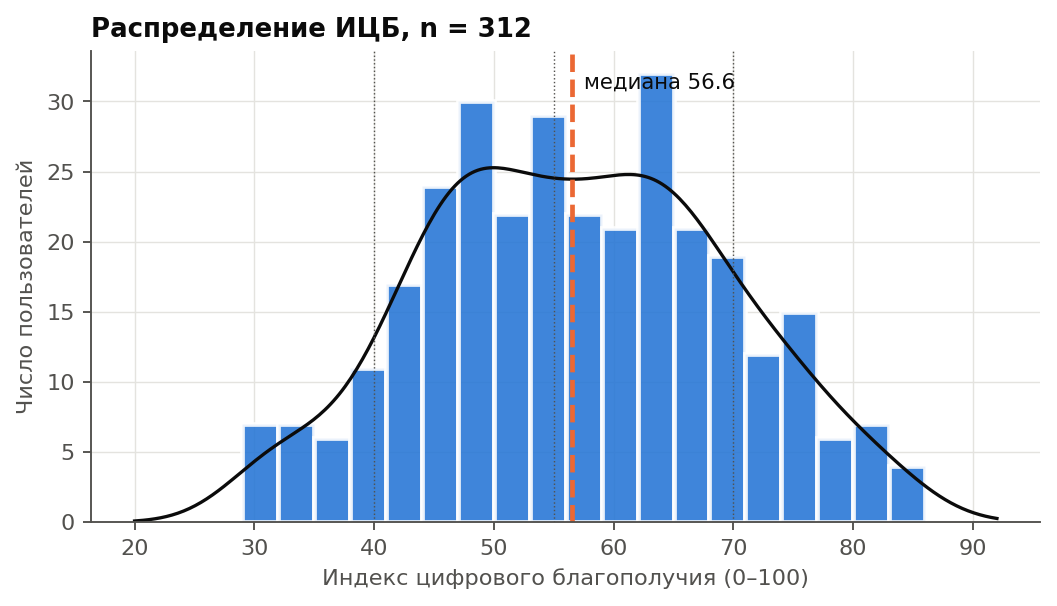

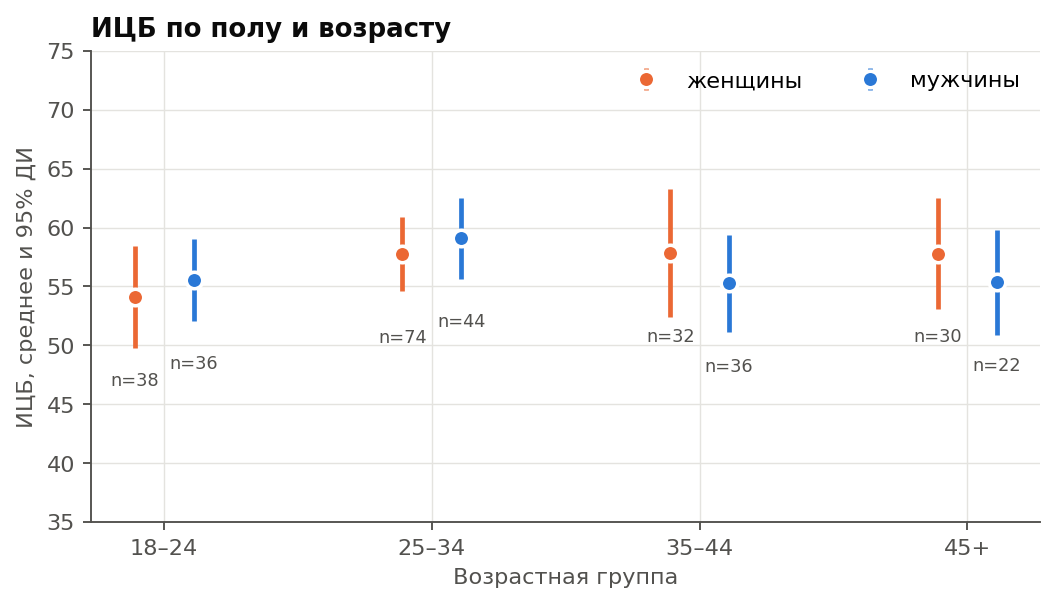

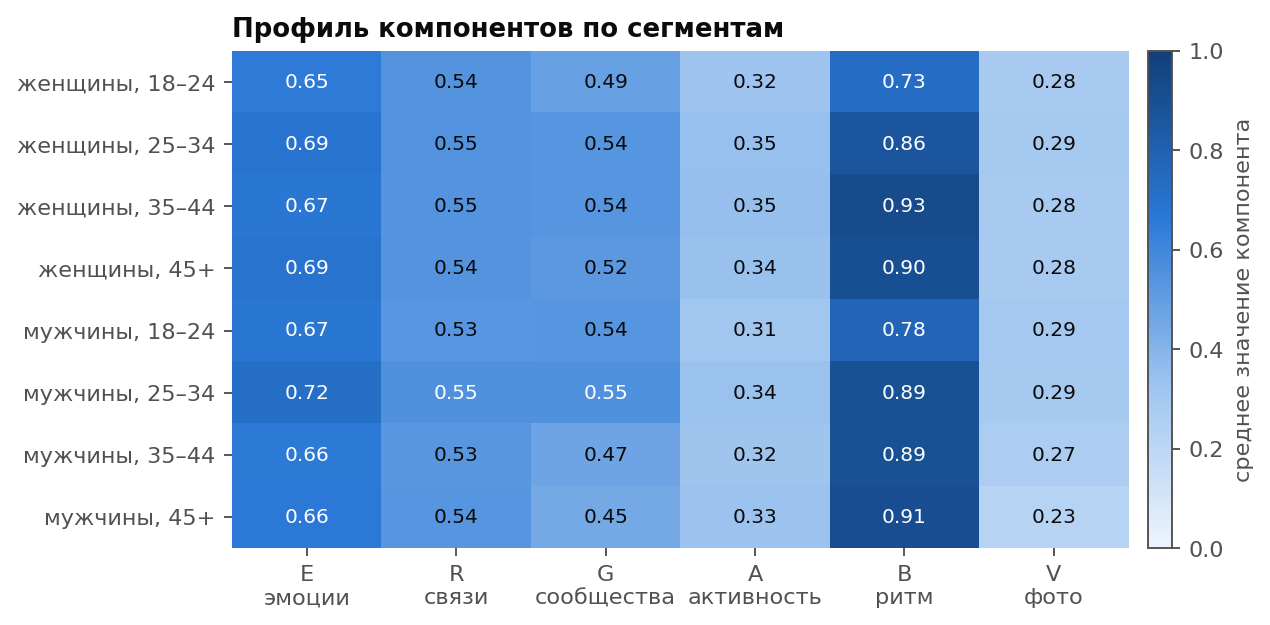

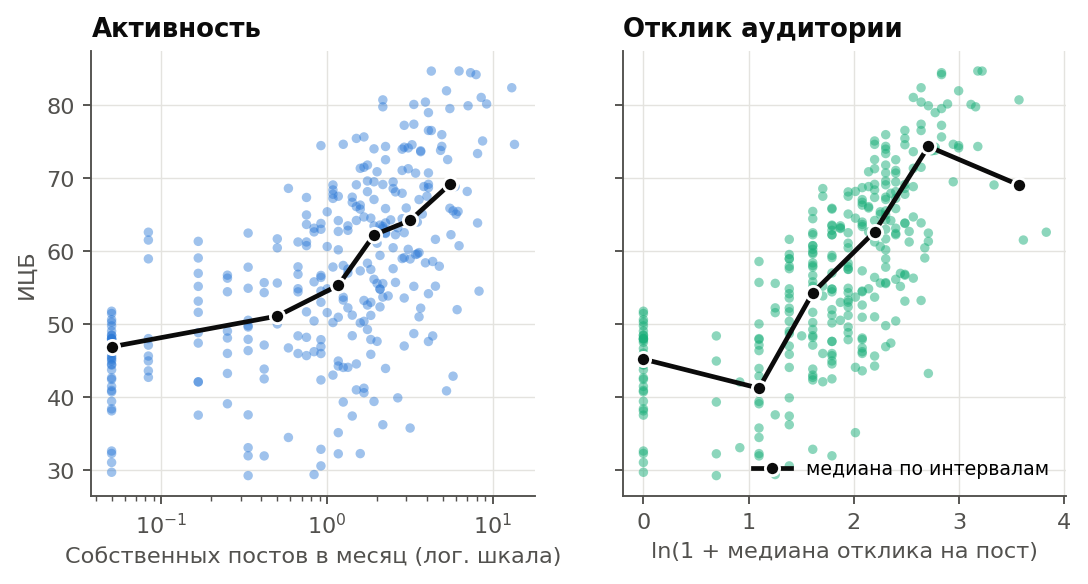

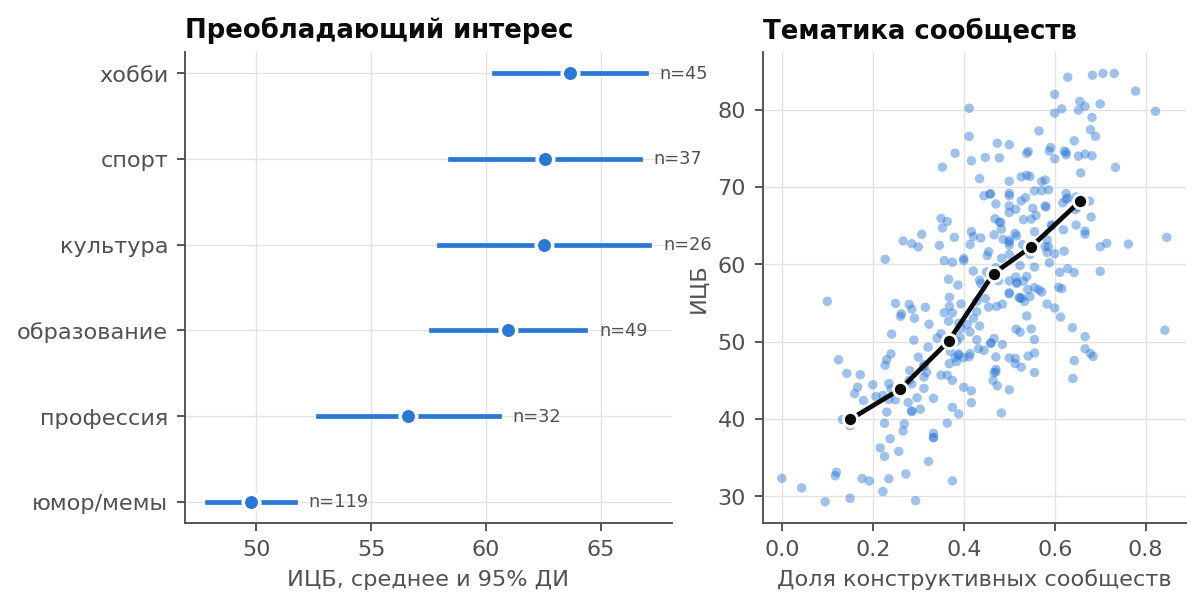

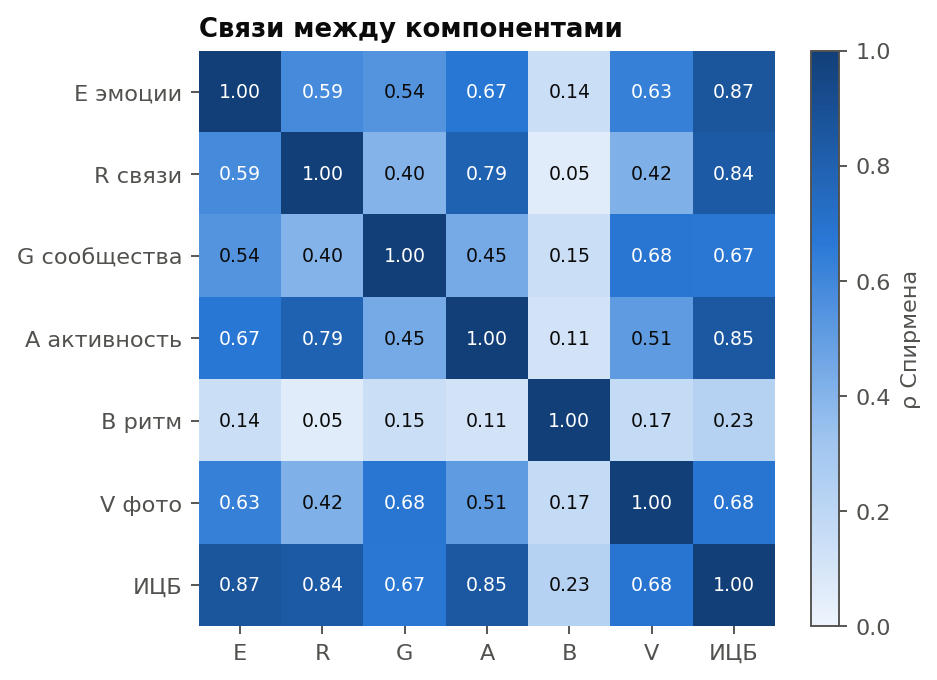

In [10]:
rhos, keep = rb.weight_sensitivity(res[["E", "R", "G", "A", "B", "V"]], n=1000)
paths = vz.make_all(res, data, rhos, keep)
for p in paths[:6]:
    display(Image(filename=str(p), width=720))

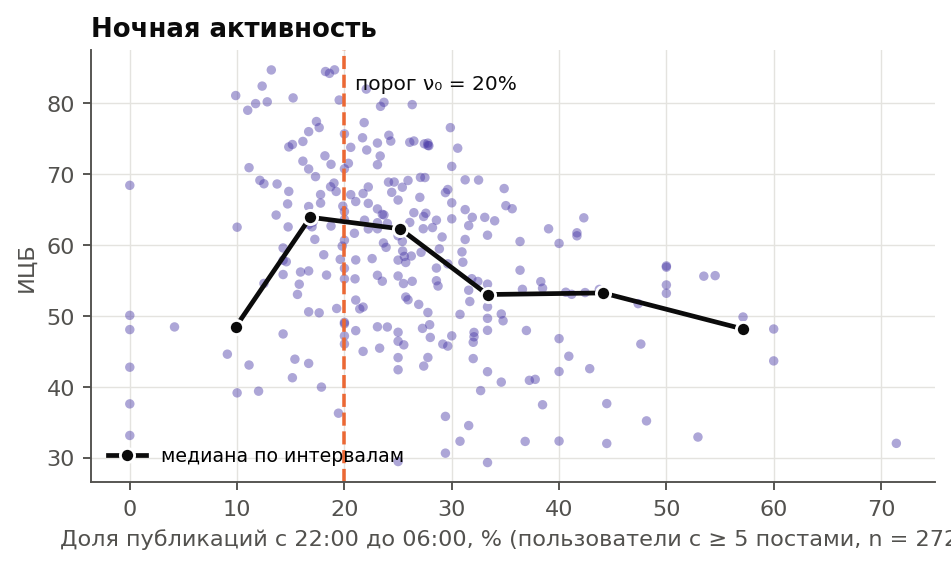

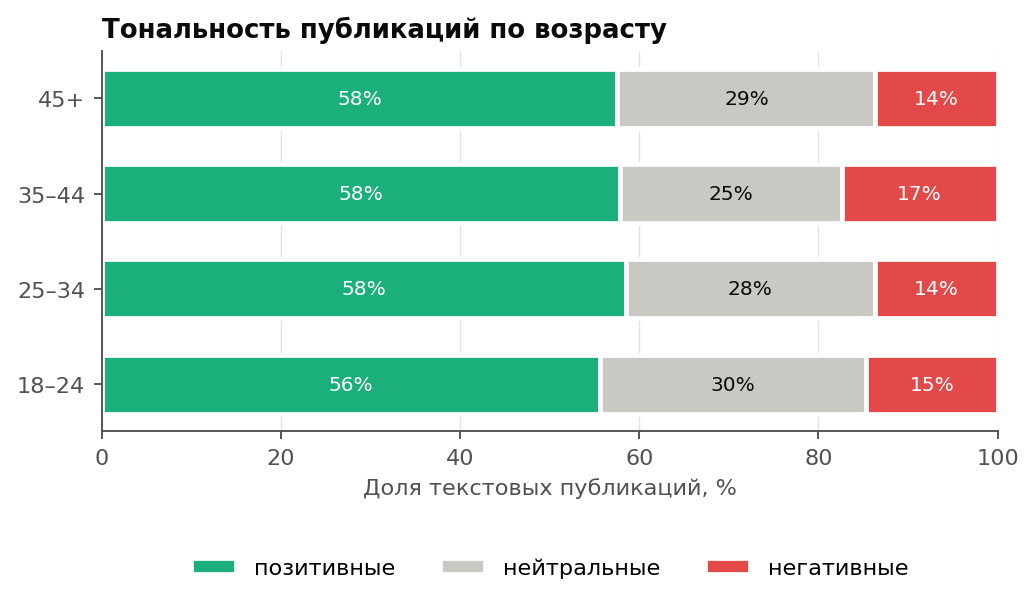

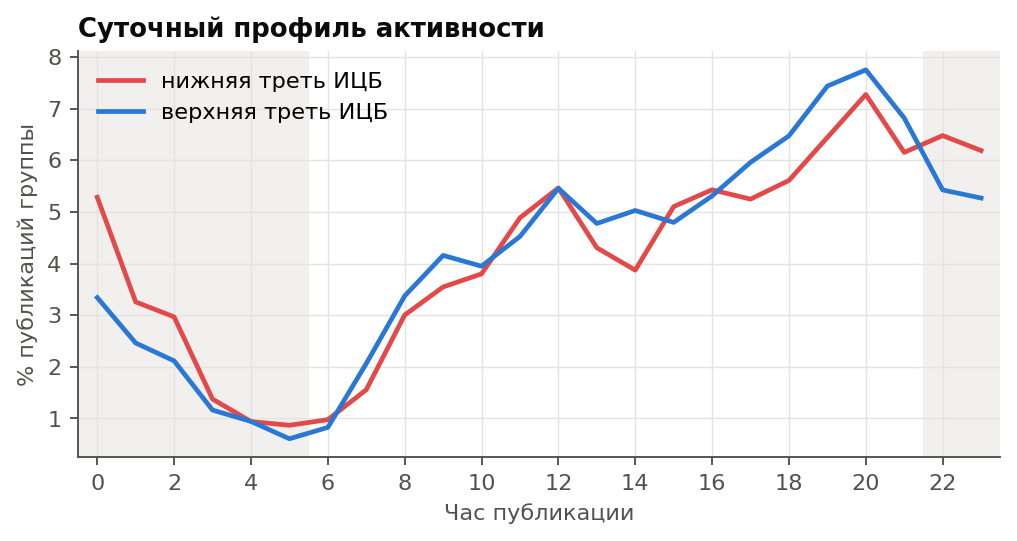

In [11]:
for p in paths[8:]:
    display(Image(filename=str(p), width=720))

## 6. Устойчивость

Случайные веса (Дирихле вокруг экспертных), удаление компонентов, искусственные выбросы и сравнение двух полугодий.

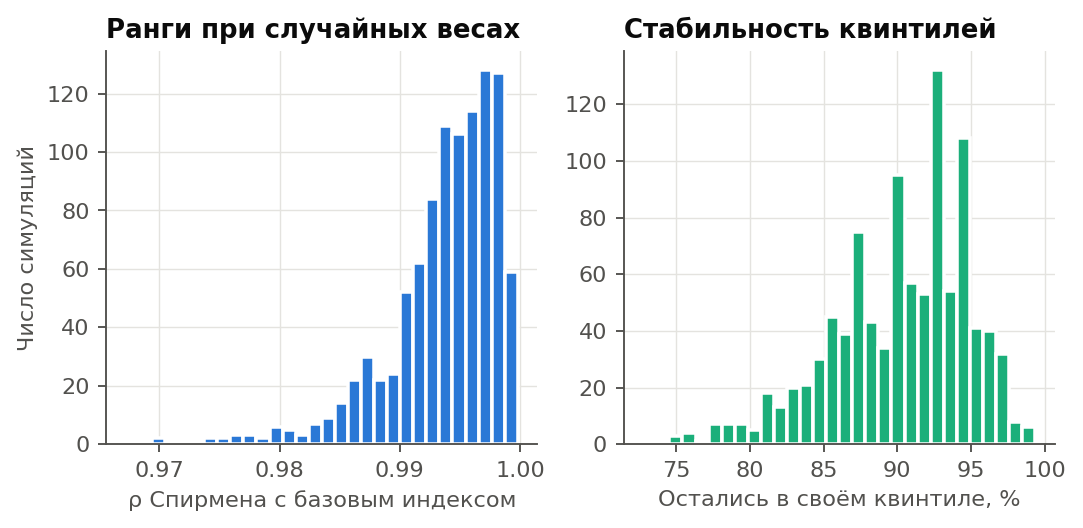

ρ с базовым индексом: медиана 0.995, 2.5% 0.981
α Кронбаха: 0.811
Без одного компонента: {'E': 0.967, 'R': 0.953, 'G': 0.982, 'A': 0.993, 'B': 0.99, 'V': 0.999}


In [12]:
display(Image(filename=str(paths[6]), width=720))
print(f"ρ с базовым индексом: медиана {np.median(rhos):.3f}, 2.5% {np.percentile(rhos, 2.5):.3f}")
print("α Кронбаха:", round(rb.cronbach_alpha(res[["E", "R", "G", "A", "B", "V"]]), 3))
print("Без одного компонента:", rb.leave_one_out(res[["E", "R", "G", "A", "B", "V"]]))

In [13]:
out = rb.outlier_test(res)
pd.DataFrame({k: {"ρ рангов остальных": v["rho_others"], "средний сдвиг": v["mean_abs_shift"],
                  **{f"оценка {o}": s for o, s in v["outliers"].items()}} for k, v in out.items()})

,DWI,naive
ρ рангов остальных,1.00,0.983
средний сдвиг,0.03,3.470
оценка _blogger,67.70,67.700
оценка _spammer,55.50,12.800
оценка _negative,41.40,5.500


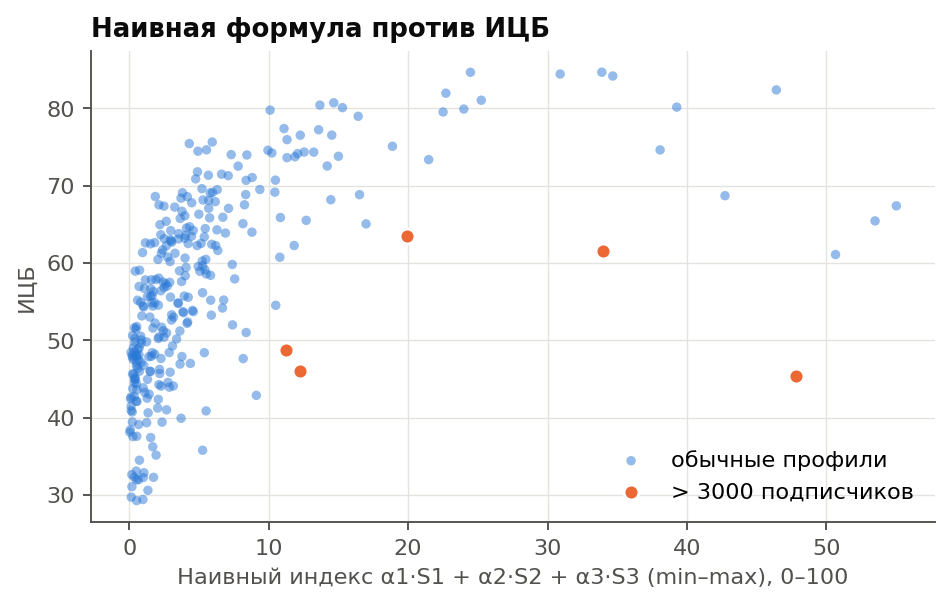

Стабильность между полугодиями: ρ = 0.88 (n = 234)


In [14]:
display(Image(filename=str(paths[7]), width=680))
rho, n = rb.temporal_stability(data, sa, cache)
print(f"Стабильность между полугодиями: ρ = {rho:.2f} (n = {n})")

## 7. Выводы

* Индекс сильнее всего связан с «ядром» близких контактов, откликом на посты и долей конструктивных сообществ; число подписчиков почти ничего не решает.
* Депрессивные и токсичные паблики и ночная активность тянут индекс вниз.
* Ранги устойчивы к выбору весов и к выбросам, чего нельзя сказать о наивной сумме друзей, постов и лайков.
* Это групповая метрика цифровой «витрины», а не диагноз: соцсети показывают то, что человек хочет показать. Следующий шаг — валидация на добровольцах через шкалы SWLS и WHO-5.